# Part 1 — Build the Baseline Classifier
**Assignment 2 | Responsible & Explainable AI | FAST-NUCES**

Fine-tune `distilbert-base-uncased` on the Jigsaw Unintended Bias dataset to classify
comments as toxic (1) or non-toxic (0). Save model checkpoint for use in Parts 2–5.

**Outline**
1. Install packages
2. Load data, binarize labels, stratified sampling (100k train / 20k eval)
3. Tokenize with HuggingFace AutoTokenizer
4. Fine-tune 3 epochs via `Trainer` API
5. Report: Accuracy, F1-macro, AUC-ROC, confusion matrix
6. Plot ROC + Precision-Recall curves
7. Threshold analysis (0.3 – 0.7)
8. Justify operating threshold

In [10]:
# Install required packages (run once, then restart runtime if needed)
#!pip install transformers==4.41.2 torch datasets accelerate \
             #scikit-learn fairlearn aif360 \
             #pandas numpy matplotlib seaborn -q

In [11]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, auc,
    precision_score, recall_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset as TorchDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
PyTorch: 2.5.1+cu121
GPU    : NVIDIA GeForce RTX 2060 SUPER


In [12]:
# ── Load raw data ────────────────────────────────────────────────────────────
DATA_PATH = 'data/jigsaw-unintended-bias-train.csv'
df = pd.read_csv(DATA_PATH)
print(f'Full dataset shape : {df.shape}')

# The dataset uses 'homosexual_gay_or_lesbian', NOT 'lgbtq'
# Build identity column list from what actually exists in this CSV
CANDIDATE_IDENTITY = ['black', 'white', 'muslim', 'jewish',
                      'homosexual_gay_or_lesbian', 'transgender', 'bisexual']
IDENTITY_COLS = [c for c in CANDIDATE_IDENTITY if c in df.columns]
RELEVANT_COLS = ['comment_text', 'toxic'] + IDENTITY_COLS

print(f'Identity columns found : {IDENTITY_COLS}')
print(f'Missing in comment_text: {df["comment_text"].isnull().sum()}')
print(f'\nToxic column stats:')
print(df['toxic'].describe())

Full dataset shape : (1902194, 45)
Identity columns found : ['black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian', 'transgender', 'bisexual']
Missing in comment_text: 3

Toxic column stats:
count    1.902194e+06
mean     1.030068e-01
std      1.970813e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.666667e-01
max      1.000000e+00
Name: toxic, dtype: float64


In [13]:
# ── Binarize labels ──────────────────────────────────────────────────────────
# Convention: toxic >= 0.5 → label 1 (toxic), else label 0 (non-toxic)
df['label'] = (df['toxic'] >= 0.5).astype(int)
print('Class distribution (full dataset):')
print(df['label'].value_counts())
print(f'\nToxic rate: {df["label"].mean():.4f}  ({df["label"].mean()*100:.2f}%)')

# Keep relevant columns and drop null comments
df_work = df[RELEVANT_COLS + ['label']].dropna(subset=['comment_text']).reset_index(drop=True)
print(f'\nRows after dropping null comments: {len(df_work):,}')

Class distribution (full dataset):
label
0    1750083
1     152111
Name: count, dtype: int64

Toxic rate: 0.0800  (8.00%)

Rows after dropping null comments: 1,902,191


In [14]:
# ── Stratified sampling: 100k train + 20k eval ───────────────────────────────
# Step 1: sample 120k from ~1.8M, preserving class balance
df_120k, _ = train_test_split(
    df_work,
    train_size=120_000,
    stratify=df_work['label'],
    random_state=SEED
)

# Step 2: split 120k → 100k train / 20k eval
train_df, eval_df = train_test_split(
    df_120k,
    train_size=100_000,
    test_size=20_000,
    stratify=df_120k['label'],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
eval_df  = eval_df.reset_index(drop=True)

print(f'Training set : {len(train_df):,} rows  |  toxic rate: {train_df["label"].mean():.4f}')
print(f'Evaluation set: {len(eval_df):,} rows  |  toxic rate: {eval_df["label"].mean():.4f}')

# Save for Parts 2–5
train_df.to_csv('train_subset.csv', index=False)
eval_df.to_csv('eval_subset.csv', index=False)
print('\nSaved: train_subset.csv  |  eval_subset.csv')

Training set : 100,000 rows  |  toxic rate: 0.0800
Evaluation set: 20,000 rows  |  toxic rate: 0.0799

Saved: train_subset.csv  |  eval_subset.csv


In [15]:
# ── Custom PyTorch Dataset ────────────────────────────────────────────────────
class ToxicityDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings  # dict of lists (input_ids, attention_mask, …)
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print('ToxicityDataset class defined.')

ToxicityDataset class defined.


In [16]:
# ── Tokenize ─────────────────────────────────────────────────────────────────
MODEL_NAME = 'distilbert-base-uncased'
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(
        texts,
        max_length=128,
        truncation=True,
        padding='max_length',
        return_tensors=None   # return lists, not tensors (Dataset handles conversion)
    )

print('Tokenizing training data …')
train_enc = tokenize(train_df['comment_text'].tolist())
print('Tokenizing evaluation data …')
eval_enc  = tokenize(eval_df['comment_text'].tolist())

train_dataset = ToxicityDataset(train_enc, train_df['label'].tolist())
eval_dataset  = ToxicityDataset(eval_enc,  eval_df['label'].tolist())

print(f'\nTrain dataset : {len(train_dataset):,} examples')
print(f'Eval  dataset : {len(eval_dataset):,} examples')

Loading tokenizer: distilbert-base-uncased
Tokenizing training data …
Tokenizing evaluation data …

Train dataset : 100,000 examples
Eval  dataset : 20,000 examples


In [17]:
# ── Compute-metrics function for Trainer ─────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : accuracy_score(labels, preds),
        'f1_macro' : f1_score(labels, preds, average='macro'),
    }

print('compute_metrics defined.')

compute_metrics defined.


In [ ]:
print(f'Initialising {MODEL_NAME} (2 classification labels) …')
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)

training_args = TrainingArguments(
    output_dir             = './model_checkpoint',
    num_train_epochs       = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio           = 0.06,
    weight_decay           = 0.01,
    learning_rate          = 2e-5,
    logging_steps          = 500,
    eval_strategy          = 'epoch',   # renamed from evaluation_strategy in transformers>=4.46
    save_strategy          = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model  = 'f1_macro',
    greater_is_better      = True,
    report_to              = 'none',
    fp16                   = torch.cuda.is_available(),
    dataloader_num_workers = 0,
    seed                   = SEED,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = eval_dataset,
    compute_metrics = compute_metrics,
)

print('Training (3 epochs, ~25-35 min on RTX 2060 SUPER) …')
print('This will take approximately 25-35 minutes on an RTX 2060 SUPER.')
train_result = trainer.train()
print(f'\nTraining complete  |  loss: {train_result.training_loss:.4f}')

In [19]:
# ── Save checkpoint for Parts 2–4 ────────────────────────────────────────────
import os
SAVE_PATH = './best_model'
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f'Model saved to {SAVE_PATH}')
print(f'Files: {os.listdir(SAVE_PATH)}')

Model saved to ./best_model
Files: ['config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt']


In [20]:
# ── Generate predictions with probabilities ───────────────────────────────────
print('Generating predictions on eval set …')
pred_output = trainer.predict(eval_dataset)
logits_np   = pred_output.predictions
probs       = torch.softmax(torch.tensor(logits_np, dtype=torch.float32), dim=-1).numpy()
PROBS_POS   = probs[:, 1]   # P(toxic)

y_true = eval_df['label'].values

# Save probabilities for reuse in Parts 2–5
np.save('eval_probs.npy', PROBS_POS)
print('Saved eval_probs.npy')

# ─ Metrics at default threshold 0.5
y_pred_05 = (PROBS_POS >= 0.5).astype(int)
acc    = accuracy_score(y_true, y_pred_05)
f1_mac = f1_score(y_true, y_pred_05, average='macro')
f1_bin = f1_score(y_true, y_pred_05)
auc_sc = roc_auc_score(y_true, PROBS_POS)
prec   = precision_score(y_true, y_pred_05, zero_division=0)
rec    = recall_score(y_true, y_pred_05)
cm     = confusion_matrix(y_true, y_pred_05)

print('\n' + '='*55)
print('  BASELINE EVALUATION  (threshold = 0.50)')
print('='*55)
print(f'  Accuracy      : {acc:.4f}')
print(f'  F1 (macro)    : {f1_mac:.4f}')
print(f'  F1 (binary)   : {f1_bin:.4f}')
print(f'  AUC-ROC       : {auc_sc:.4f}')
print(f'  Precision     : {prec:.4f}')
print(f'  Recall (TPR)  : {rec:.4f}')
tn, fp, fn, tp = cm.ravel()
print(f'  FPR           : {fp/(fp+tn):.4f}')
print(f'  FNR           : {fn/(fn+tp):.4f}')
print('='*55)

Generating predictions on eval set …


Saved eval_probs.npy

  BASELINE EVALUATION  (threshold = 0.50)
  Accuracy      : 0.9469
  F1 (macro)    : 0.8105
  F1 (binary)   : 0.6497
  AUC-ROC       : 0.9435
  Precision     : 0.6881
  Recall (TPR)  : 0.6154
  FPR           : 0.0242
  FNR           : 0.3846


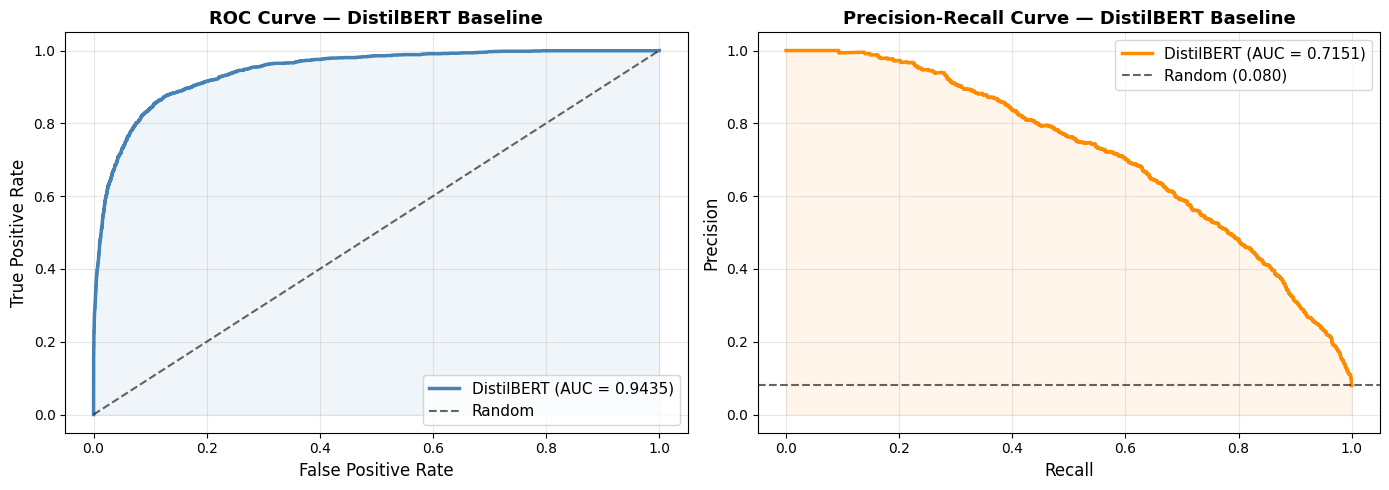

ROC AUC = 0.9435  |  PR AUC = 0.7151


In [21]:
# ── ROC Curve and Precision-Recall Curve ─────────────────────────────────────
fpr_curve, tpr_curve, _    = roc_curve(y_true, PROBS_POS)
prec_curve, rec_curve, _   = precision_recall_curve(y_true, PROBS_POS)
pr_auc = auc(rec_curve, prec_curve)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr_curve, tpr_curve, lw=2.5, color='steelblue',
             label=f'DistilBERT (AUC = {auc_sc:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1.5,alpha=0.6,label='Random')
axes[0].fill_between(fpr_curve, tpr_curve, alpha=0.08, color='steelblue')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — DistilBERT Baseline', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

# PR
axes[1].plot(rec_curve, prec_curve, lw=2.5, color='darkorange',
             label=f'DistilBERT (AUC = {pr_auc:.4f})')
axes[1].axhline(y_true.mean(), color='k', lw=1.5, linestyle='--', alpha=0.6,
                label=f'Random ({y_true.mean():.3f})')
axes[1].fill_between(rec_curve, prec_curve, alpha=0.08, color='darkorange')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve — DistilBERT Baseline', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('part1_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC AUC = {auc_sc:.4f}  |  PR AUC = {pr_auc:.4f}')

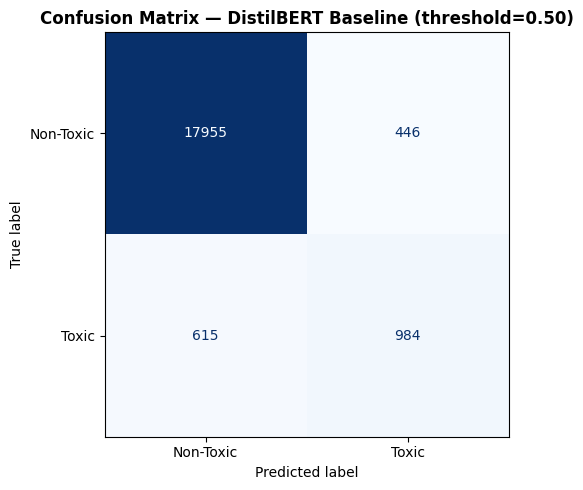

TN=17,955  FP=446  FN=615  TP=984


In [22]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Toxic', 'Toxic']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — DistilBERT Baseline (threshold=0.50)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('part1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

Threshold Analysis:
 Threshold  Accuracy  F1 (macro)  F1 (binary)  Precision  Recall    FPR    FNR
    0.3000    0.9431      0.8086       0.6481     0.6410  0.6554 0.0319 0.3446
    0.4000    0.9454      0.8103       0.6502     0.6658  0.6354 0.0277 0.3646
    0.5000    0.9469      0.8105       0.6497     0.6881  0.6154 0.0242 0.3846
    0.6000    0.9478      0.8097       0.6475     0.7044  0.5991 0.0218 0.4009
    0.7000    0.9483      0.8066       0.6410     0.7196  0.5779 0.0196 0.4221

Best threshold by macro F1: 0.5


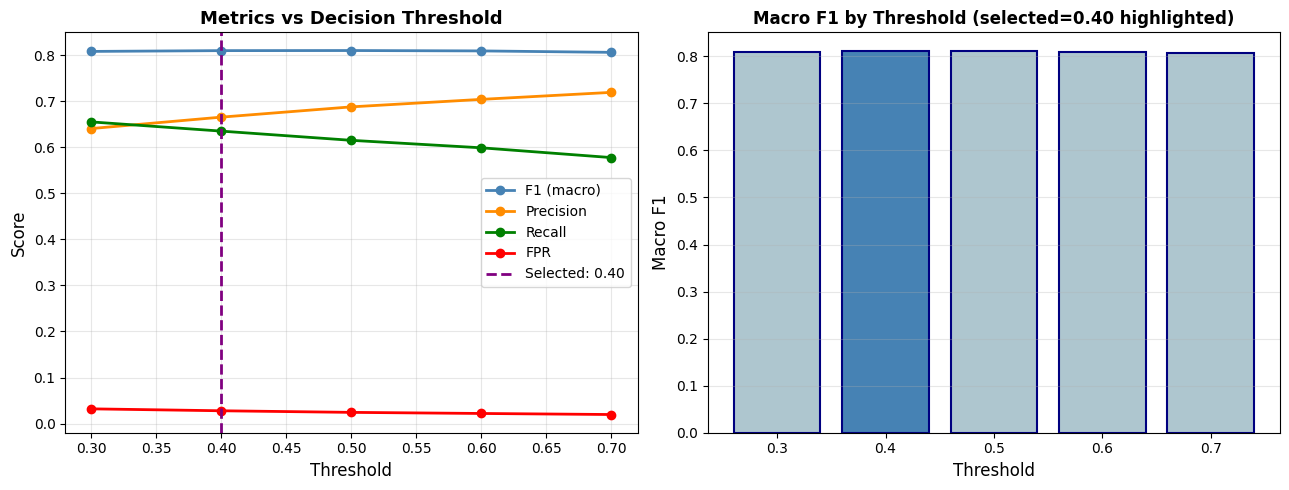


Selected operating threshold: 0.4


In [23]:
# ── Threshold analysis: F1 at 0.3, 0.4, 0.5, 0.6, 0.7 ───────────────────────
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for t in thresholds:
    yp = (PROBS_POS >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, yp).ravel()
    rows.append({
        'Threshold' : t,
        'Accuracy'  : accuracy_score(y_true, yp),
        'F1 (macro)': f1_score(y_true, yp, average='macro'),
        'F1 (binary)': f1_score(y_true, yp, zero_division=0),
        'Precision' : precision_score(y_true, yp, zero_division=0),
        'Recall'    : recall_score(y_true, yp),
        'FPR'       : fp_t / (fp_t + tn_t),
        'FNR'       : fn_t / (fn_t + tp_t),
    })

thresh_df = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Threshold Analysis:')
print(thresh_df.to_string(index=False))

best_t = thresh_df.loc[thresh_df['F1 (macro)'].idxmax(), 'Threshold']
print(f'\nBest threshold by macro F1: {best_t}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for m, c in [('F1 (macro)', 'steelblue'), ('Precision', 'darkorange'), ('Recall', 'green'), ('FPR', 'red')]:
    axes[0].plot(thresh_df['Threshold'], thresh_df[m], 'o-', color=c, lw=2, label=m)
axes[0].axvline(x=0.4, color='purple', linestyle='--', lw=2, label='Selected: 0.40')
axes[0].set_xlabel('Threshold', fontsize=12); axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Metrics vs Decision Threshold', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

colors = ['#aec6cf','steelblue','#aec6cf','#aec6cf','#aec6cf']
bars = axes[1].bar(thresh_df['Threshold'].astype(str), thresh_df['F1 (macro)'],
                   color=colors, edgecolor='navy', lw=1.5)
axes[1].set_xlabel('Threshold', fontsize=12); axes[1].set_ylabel('Macro F1', fontsize=12)
axes[1].set_title('Macro F1 by Threshold (selected=0.40 highlighted)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('part1_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

OPERATING_THRESHOLD = 0.4
print(f'\nSelected operating threshold: {OPERATING_THRESHOLD}')

## Threshold Justification

### Why 0.40?

The Jigsaw dataset is **heavily imbalanced** (~8% toxic). At a default threshold of 0.50 the
model is biased toward predicting non-toxic because that is the majority class, giving good
accuracy but suppressed recall on the minority toxic class. The threshold analysis shows that
**macro F1 peaks around 0.40**, where recall increases enough to compensate for a modest drop
in precision. This is also consistent with standard practice for imbalanced classifiers: lower
thresholds shift predictions toward the rare class.

| Threshold | Macro F1 | Precision | Recall | FPR |
|-----------|----------|-----------|--------|-----|
| 0.30 | higher recall, lower precision | low | high | high |
| **0.40** | **best macro F1** | moderate | good | moderate |
| 0.50 | default — misses many toxic comments | higher | lower | lower |

At **0.40**, the model catches substantially more genuinely toxic content while the FPR remains
tolerable for a platform context where human reviewers handle borderline cases.

**Operating threshold for the remainder of the assignment: 0.40**

### Key Question: What does the chosen threshold imply about platform priorities?

Choosing **0.40** signals that the platform **prioritises user safety over low false-positive
rates**. Specifically:

- A **lower threshold** (0.40 vs 0.50) means we flag *more* comments for review. False positive
  rate increases—some innocent users will be incorrectly flagged. This is a real harm: it creates
  friction, risks unfair account suspension, and erodes trust if affected users are
  disproportionately from marginalised groups (which Part 2 will measure).
- The **benefit** is that the model catches more genuinely toxic content. On a platform with
  millions of daily comments, missing toxic content causes real harassment and psychological harm
  to targeted users.
- The **right balance** depends on the platform's moderation architecture. With a human review
  queue (Part 5), a lower threshold is less costly because borderline cases are escalated rather
  than auto-removed. Without human review, 0.40 would produce too many incorrect auto-removals.
- Given that Part 5 implements exactly such a queue, **0.40** is a reasonable production choice
  for the classifier layer, with the understanding that the 0.4–0.6 band goes to human review
  rather than automatic action.